# Supply Chain Analytics - Anomaly Detection

## Objective

The objective of this notebook is to identify unusual demand patterns in the
supply chain using statistical anomaly detection techniques.

Methods used:

- Z-Score
- Interquartile Range (IQR)

The detected anomalies may indicate unexpected demand spikes, stock issues,
promotions, seasonal events, or operational problems.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

plt.style.use("default")

pd.set_option("display.max_columns", None)

In [5]:
daily_sales= pd.read_csv("../data/cleaned/retail_store_inventory_cleaned.csv",parse_dates=["Date"])

daily_sales.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [6]:
daily_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[us]
 1   Store ID            73100 non-null  str           
 2   Product ID          73100 non-null  str           
 3   Category            73100 non-null  str           
 4   Region              73100 non-null  str           
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  str           
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64       
 14  S

In [7]:
daily_sales.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2023-01-01 00:00:00,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


## Z-Score Method

The Z-Score measures how many standard deviations each observation is from
the mean.

Values with an absolute Z-Score greater than 3 are considered potential
anomalies.

In [8]:
daily_sales["Z_Score"] = zscore(daily_sales["Units Sold"])

In [9]:
zscore_anomalies = daily_sales[
    daily_sales["Z_Score"].abs() > 3]

zscore_anomalies

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Z_Score
102,2022-01-02,S001,P0003,Clothing,South,488,464,163,463.12,70.99,10,Snowy,0,72.93,Summer,3.007153
138,2022-01-02,S002,P0019,Toys,East,492,479,132,469.74,79.11,0,Cloudy,0,80.06,Winter,3.144871
554,2022-01-06,S003,P0015,Furniture,North,490,476,53,478.76,20.66,0,Rainy,1,16.87,Winter,3.117327
750,2022-01-08,S003,P0011,Furniture,East,482,480,68,480.66,74.14,20,Snowy,0,73.20,Winter,3.154052
1512,2022-01-16,S001,P0013,Furniture,South,482,482,62,472.40,62.11,5,Rainy,0,61.24,Summer,3.172414
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71557,2023-12-17,S003,P0018,Furniture,North,489,485,81,475.20,51.73,10,Rainy,1,50.46,Spring,3.199958
71558,2023-12-17,S003,P0019,Clothing,South,479,473,167,474.13,11.35,15,Rainy,1,6.44,Spring,3.089784
72485,2023-12-26,S005,P0006,Groceries,West,498,482,33,488.92,34.79,10,Sunny,1,31.68,Autumn,3.172414
72884,2023-12-30,S005,P0005,Furniture,East,498,472,169,485.17,95.79,20,Sunny,1,98.65,Summer,3.080603


In [10]:
print("Total Z-Score Anomalies:", len(zscore_anomalies))

Total Z-Score Anomalies: 236


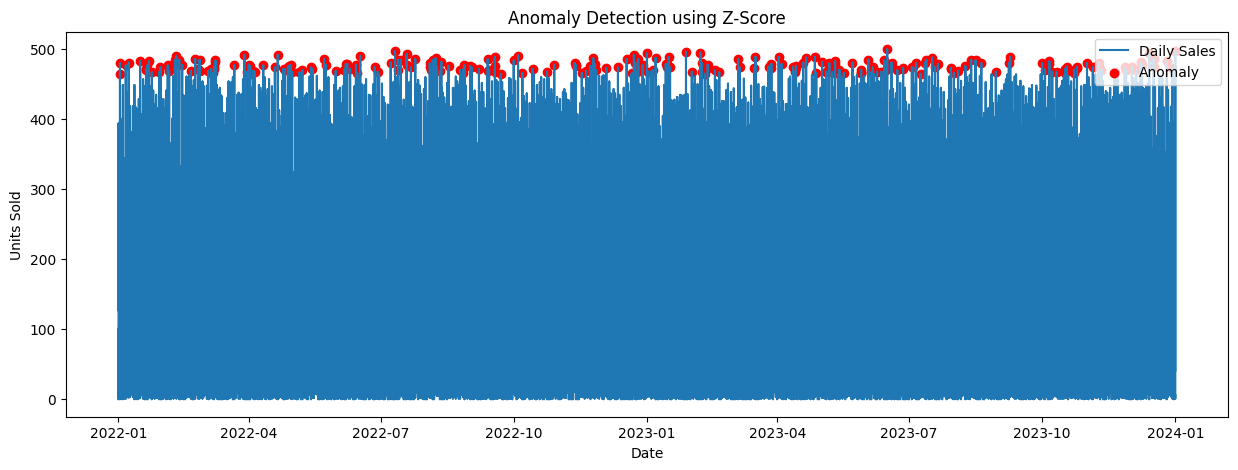

In [11]:
plt.figure(figsize=(15,5))

plt.plot(
    daily_sales["Date"],
    daily_sales["Units Sold"],
    label="Daily Sales")

plt.scatter(
    zscore_anomalies["Date"],
    zscore_anomalies["Units Sold"],
    color="red",
    label="Anomaly")

plt.title("Anomaly Detection using Z-Score")

plt.xlabel("Date")

plt.ylabel("Units Sold")

plt.legend()

plt.show()